In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [2]:
env = gym.make('CartPole-v1')

In [3]:
ALPHA = 0.1         # Learning Rate (Constant as per your task)
GAMMA = 0.99        # Discount Factor (Future reward importance)
EPSILON = 1.0       # Exploration Rate
EPS_DECAY = 0.998   # How fast to stop being random
MIN_EPS = 0.01      # Minimum randomness

In [4]:
num_bins = (1, 1, 10, 10) 
state_bounds = list(zip(env.observation_space.low, env.observation_space.high))
state_bounds[1] = [-3.0, 3.0] # Limit velocity range for better bins
state_bounds[3] = [-3.5, 3.5] # Limit angular velocity

q_table = np.zeros(num_bins + (env.action_space.n,))

In [5]:
def discretize_state(state):
    indices = []
    for i in range(len(state)):
        bin_range = np.linspace(state_bounds[i][0], state_bounds[i][1], num_bins[i] + 1)[1:-1]
        indices.append(np.digitize(state[i], bin_range))
    return tuple(indices)

In [8]:
episodes = 10000
total_rewards = []

for ep in range(episodes):
    state, _ = env.reset()
    state_idx = discretize_state(state)
    episode_reward = 0
    done = False
    
    while not done:
        if np.random.random() < EPSILON:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state_idx])
            
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        next_idx = discretize_state(next_state)
        
        current_q = q_table[state_idx + (action,)]
        max_future_q = np.max(q_table[next_idx])
        
        new_q = current_q + ALPHA * (reward + GAMMA * max_future_q - current_q)
        q_table[state_idx + (action,)] = new_q
        
        state_idx = next_idx
        episode_reward += reward
        
    EPSILON = max(MIN_EPS, EPSILON * EPS_DECAY)
    total_rewards.append(episode_reward)

    if (ep + 1) % 100 == 0:
        print(f"Episode: {ep+1} | Avg Reward: {np.mean(total_rewards[-100:]):.1f} | Epsilon: {EPSILON:.2f}")

Episode: 100 | Avg Reward: 185.2 | Epsilon: 0.01
Episode: 200 | Avg Reward: 182.1 | Epsilon: 0.01
Episode: 300 | Avg Reward: 184.3 | Epsilon: 0.01
Episode: 400 | Avg Reward: 188.3 | Epsilon: 0.01
Episode: 500 | Avg Reward: 181.8 | Epsilon: 0.01
Episode: 600 | Avg Reward: 184.4 | Epsilon: 0.01
Episode: 700 | Avg Reward: 184.1 | Epsilon: 0.01
Episode: 800 | Avg Reward: 178.7 | Epsilon: 0.01
Episode: 900 | Avg Reward: 189.0 | Epsilon: 0.01
Episode: 1000 | Avg Reward: 183.7 | Epsilon: 0.01
Episode: 1100 | Avg Reward: 187.3 | Epsilon: 0.01
Episode: 1200 | Avg Reward: 183.5 | Epsilon: 0.01
Episode: 1300 | Avg Reward: 186.0 | Epsilon: 0.01
Episode: 1400 | Avg Reward: 186.7 | Epsilon: 0.01
Episode: 1500 | Avg Reward: 190.8 | Epsilon: 0.01
Episode: 1600 | Avg Reward: 181.0 | Epsilon: 0.01
Episode: 1700 | Avg Reward: 183.9 | Epsilon: 0.01
Episode: 1800 | Avg Reward: 181.3 | Epsilon: 0.01
Episode: 1900 | Avg Reward: 182.1 | Epsilon: 0.01
Episode: 2000 | Avg Reward: 186.9 | Epsilon: 0.01
Episode: 

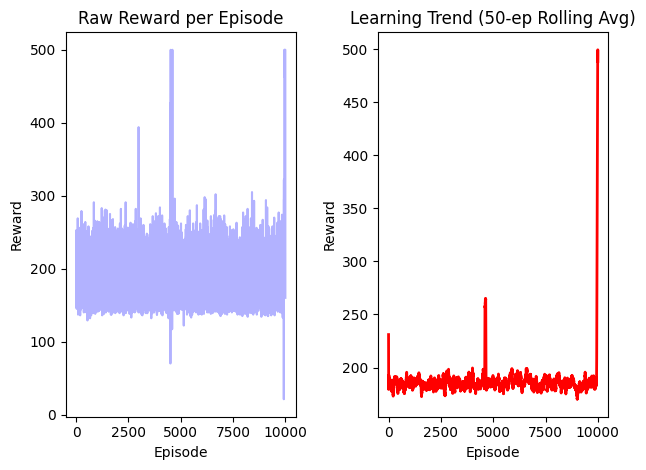

In [9]:
plt.subplot(1, 2, 1)
plt.plot(total_rewards, color='blue', alpha=0.3)
plt.title("Raw Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")

# Plot 2: Learning Trend (Rolling Average)
plt.subplot(1, 2, 2)
rolling_avg = [np.mean(total_rewards[max(0, i-50):i+1]) for i in range(len(total_rewards))]
plt.plot(rolling_avg, color='red', linewidth=2)
plt.title("Learning Trend (50-ep Rolling Avg)")
plt.xlabel("Episode")
plt.ylabel("Reward")

plt.tight_layout()
plt.show()